# Semantic Share Check — K = 150

Does the tokenizer's k=150 candidate set group clinically related concepts together more than a
random k=150 subset would? Ground truth: the expert-labeled concept taxonomy built from
`config.TimelineData().used_cpt` (same source 6.5 uses for `concepts_of_interest`), joined to the
vocab and restricted to its clinically-meaningful categories -- see Step 1 for exactly how that
restriction is derived, since it isn't handed to us as a separate file.

Real methods compared: `lam_0.6`, `lam_0.8`, `lam_1.0` (greedy tree), `personalized_pagerank` --
all read from the existing `config.IACandidateLists()` rankings (the same ones used throughout
6.2-6.4), sliced to k=150. `discrete_set_cover` is carried through as a labeled known-poor
reference only (see the note in Step 2), never averaged into the main result.

In [ ]:
import os
import json
import pickle
from collections import Counter, defaultdict
from itertools import combinations

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

import src.graph_tokenizer_gd_tree_dev.config as config
import src.graph_tokenizer_gd_tree_dev.tokenizer as tokenizer
import src.graph_tokenizer_gd_tree_dev.eval as eval
import src.graph_tokenizer_gd_tree_dev.graph_fct as graph_fct

In [63]:
K = 150
N_RANDOM_REPLICATES = 50  # the spec says "repeat 10 times" in step 3 but "50-replicate" in step 5/6 --
                          # using 50 throughout (finer empirical-p resolution under BH correction); change
                          # this one constant to reproduce the 10-replicate reading instead
RANDOM_SEED = 0

EXCLUDED_TAXONOMY_CATEGORIES = ["blood_groups", "units"]  # see markdown below -- not clinical concept groups

## Step 1 — Prepare ground truth

There's no separate "concept taxonomy" file in the repo. The closest thing is the same
`category`/`term`/`label` table 6.5 builds from `config.TimelineData().used_cpt` for
`concepts_of_interest` -- so that's the source here too. Parsed and joined to the vocab as-is, it
comes out to 43 categories / 81 labels, which includes two categories that aren't clinical concept
groups at all: `blood_groups` (ABO blood type: A/A+/A-/B/.../O-) and `units` (measurement units:
mmol/L, g, %, ...). Dropping exactly those two categories brings the table to **41 categories / 56
labels** -- matching the spec's expected shape -- so that's the filter applied below.

In [96]:
with open(config.TimelineData().used_cpt) as f:
    raw = json.load(f)

rows = []
for category, terms in raw.items():
    if isinstance(terms, dict):
        for term, label in terms.items():
            rows.append({"category": category, "term": term, "label": label})
    elif isinstance(terms, list):
        for term in terms:
            rows.append({"category": category, "term": term, "label": None})
    else:
        rows.append({"category": category, "term": None, "label": terms})

df_raw = pl.DataFrame(rows)
print(f"raw cpt_used.json: {len(df_raw):,} rows, {df_raw['category'].n_unique()} categories, {df_raw['label'].n_unique()} labels")

df_taxonomy_candidates = df_raw.filter(~pl.col("category").is_in(EXCLUDED_TAXONOMY_CATEGORIES))
print(f"after dropping {EXCLUDED_TAXONOMY_CATEGORIES}: {len(df_taxonomy_candidates):,} rows, "
      f"{df_taxonomy_candidates['category'].n_unique()} categories, {df_taxonomy_candidates['label'].n_unique()} labels")

raw cpt_used.json: 616 rows, 49 categories, 120 labels
after dropping ['blood_groups', 'units']: 591 rows, 47 categories, 95 labels


In [97]:
df_raw.filter(pl.col("category").is_in(EXCLUDED_TAXONOMY_CATEGORIES))

category,term,label
str,str,str
"""blood_groups""","""Irregular blood group antibody…","""Not specified"""
"""blood_groups""","""Blood group A (finding)""","""A"""
"""blood_groups""","""Blood group O (finding)""","""O"""
"""blood_groups""","""Blood group B (finding)""","""B"""
"""blood_groups""","""Blood group AB (finding)""","""AB"""
…,…,…
"""units""","""Seconds (qualifier value)""","""s"""
"""units""","""Meter/second (qualifier value)""","""m/s"""
"""units""","""international unit (qualifier …","""UI"""


Join `term` to a vocabulary concept id. Some `term` strings embed a leading SNOMED code
(`"229819007|Tobacco use..."`), but most don't -- they're plain concept-label text copied
straight from SNOMED. A pure code-prefix join was tried and rejected: many of these terms are
*post-coordinated* SNOMED expressions (`"80943009|Risk factor...|:{719722006|Has realization...=
110483000|Tobacco user...|}"`), where the leading code is a generic focus concept ("Risk factor")
shared across dozens of unrelated specific concepts -- parsing only that prefix collapses distinct
concepts (tobacco use, hypertension, ...) onto the same id. Plain exact-text matching against the
vocab's `label` column (mirroring 6.5's join) doesn't have that failure mode and is what's used
below. Join failures are logged explicitly, not dropped silently.

In [98]:
df_vocab_labels = pl.read_parquet(config.BasicConfig().concept_path, columns=["label", "id"])
df_joined = df_taxonomy_candidates.join(df_vocab_labels, left_on="term", right_on="label", how="left")

df_unmatched = df_joined.filter(pl.col("id").is_null())
print(f"join failures (term not found in vocab by exact label match): {len(df_unmatched):,} / {len(df_joined):,} rows")

os.makedirs(config.IAFeatures().path, exist_ok=True)
df_unmatched.select("category", "label", "term").write_parquet(f"{config.IAFeatures().path}semantic_share_k150_join_failures.parquet")
df_unmatched.select("category", "label", "term").head(20)

join failures (term not found in vocab by exact label match): 341 / 591 rows


category,label,term
str,str,str
"""smoker""","""smoker""","""Troubles mentaux et du comport…"
"""smoker""","""smoker""","""Troubles mentaux et du comport…"
"""hypertension_labels""","""Essential hypertension""","""Hypertension essentielle, non …"
"""hypertension_labels""","""Essential hypertension""","""Hypertension essentielle, non …"
"""hypertension_labels""","""Essential hypertension""","""Hypertension essentielle bénig…"
…,…,…
"""acute_kidney_failure""","""AKI""","""Insuffisance rénale aiguë, san…"
"""acute_kidney_failure""","""AKI""","""Insuffisance rénale aiguë, san…"
"""acute_kidney_failure""","""AKI""","""Insuffisance rénale aiguë, san…"


In [99]:
df_unmatched

category,term,label,id
str,str,str,str
"""smoker""","""Troubles mentaux et du comport…","""smoker""",null
"""smoker""","""Troubles mentaux et du comport…","""smoker""",null
"""hypertension_labels""","""Hypertension essentielle, non …","""Essential hypertension""",null
"""hypertension_labels""","""Hypertension essentielle, non …","""Essential hypertension""",null
"""hypertension_labels""","""Hypertension essentielle bénig…","""Essential hypertension""",null
…,…,…,…
"""features_diseases""","""moyamoya""",null,null
"""features_diseases""","""ehlers-danlos""",null,null
"""features_diseases""","""marfan_syndrome""",null,null


In [100]:
df_matched = df_joined.drop_nulls(subset=["id"])
df_taxonomy = df_matched.select("category", "label", "id").unique(subset=["id"], keep="first")  # a few concepts join under >1 term -- keep first, mirrors 6.5's df_concept_info dedup
print(f"matched rows: {len(df_matched):,}   unique concepts (deduped): {len(df_taxonomy):,}   "
      f"categories: {df_taxonomy['category'].n_unique()}   labels: {df_taxonomy['label'].n_unique()}")

matched rows: 250   unique concepts (deduped): 243   categories: 41   labels: 56


In [101]:
df_taxonomy

category,label,id
str,str,str
"""ACE""","""ACE""","""386872004+387525002"""
"""traumatic_brain_injury""","""traumatic_brain_injury""","""417746004:{363698007=89545001}"""
"""hydrocephalus""","""hydrocephalus""","""30753002"""
"""chronic_kidney_disease""","""CKD""","""431857002"""
"""alcohol_severity_map""","""3""","""27624003+7200002"""
…,…,…
"""statine""","""statine""","""373444002"""
"""myocardial_infarction""","""myocardial_infarction""","""164865005"""
"""atherosclerosis""","""atherosclerosis""","""39823006"""


Drop any `category`/`label` group with only 1 concept -- no within-group pair exists, so it
contributes nothing to the pairwise/clustering metrics below (Step 1.3 of the spec). This is done
separately per granularity: a concept can survive the `label` filter but not the `category` one, or
vice versa, so `gt_label` and `gt_category` end up as two (slightly different) concept subsets of
the same 243-concept table.

In [102]:
label_sizes = df_taxonomy.group_by("label").agg(pl.len().alias("n"))
category_sizes = df_taxonomy.group_by("category").agg(pl.len().alias("n"))

gt_label = df_taxonomy.join(label_sizes.filter(pl.col("n") >= 2).select("label"), on="label", how="inner")
gt_category = df_taxonomy.join(category_sizes.filter(pl.col("n") >= 2).select("category"), on="category", how="inner")
granularities = {"label": gt_label, "category": gt_category}

print(f"label granularity: {len(gt_label):,} concepts across {gt_label['label'].n_unique()} labels "
      f"(dropped {label_sizes.filter(pl.col('n') == 1).height} singleton labels)")
print(f"category granularity: {len(gt_category):,} concepts across {gt_category['category'].n_unique()} categories "
      f"(dropped {category_sizes.filter(pl.col('n') == 1).height} singleton categories)")

taxonomy_concepts = df_taxonomy["id"].to_list()  # union of both granularities -- tokenized once, sliced per granularity below

label granularity: 228 concepts across 41 labels (dropped 15 singleton labels)
category granularity: 238 concepts across 36 categories (dropped 5 singleton categories)


## Step 2 — Real tokenizer mapping

`var_aggregation.parquet`'s `tokens` column is the *full* found-set from
`concept_to_tokens_and_unk` (6.5/6.3) -- every token found anywhere in a concept's context tree
(its own IS_A chain plus every non-IS_A subcontext), not just one. A concept can resolve to zero,
one, or several tokens; `uncovered` flags whether *any* branch of the tree hit the depth budget
without finding one. Both are used below as-is, not collapsed to a single value at this stage.

We still rebuild 6.5's ego-graph (`concepts_of_interest` -> `combined_subgraphs` -> `adj`) here,
even though we're not re-ranking candidates with it: Step 3's random-k null has to be tokenized
against the *exact same graph* the real methods' `T`s were selected from, or the comparison isn't
apples-to-apples. 6.5 doesn't persist this graph, so it's rebuilt fresh (same construction, same
inputs, ~30s dominated by reading the SNOMED relations table once).

In [103]:
df_mapped_ia_cohort = df_raw.join(df_vocab_labels, left_on="term", right_on="label", how="left").drop_nulls()
concepts_of_interest = df_mapped_ia_cohort["id"].unique().to_list()  # 6.5's own (unfiltered) seed set -- must match exactly to reproduce its graph
assert set(taxonomy_concepts) <= set(concepts_of_interest), "taxonomy concepts must be a subset of 6.5's concepts_of_interest"

with open(config.ProcessedGraph().id_to_label, "rb") as f:  # global concept_id -> label map, reused as-is
    id_to_label = pickle.load(f)

D = config.TokenizerParam().max_dist_candidate
df_relations = pl.read_parquet(config.BasicConfig().relation_path)
df_relations = df_relations.filter(~pl.col("dst.id").is_in(config.TokenizerParam().exclude_cpt))
whole_graph = graph_fct.build_relations_graph(df_relations, col_src="src.id", col_dst="dst.id", col_relation="relation")
combined_subgraphs = graph_fct.get_combined_subgraphs_from_nodes(whole_graph, concepts_of_interest, max_distance=D)
adj = tokenizer.build_out_adjacency(combined_subgraphs)

print(f"concepts_of_interest: {len(concepts_of_interest):,}   "
      f"combined_subgraphs: {combined_subgraphs.number_of_nodes():,} nodes, {combined_subgraphs.number_of_edges():,} edges, D={D}")

concepts_of_interest: 268   combined_subgraphs: 1,633 nodes, 3,901 edges, D=3


In [104]:
def concept_to_tokens_and_unk(c, T_set, D, adj, id_to_label):
    """Same helper as 6.3/6.5: the full found-set across a concept's whole context tree, not just the root IS_A chain."""
    tree = tokenizer.tokenize_all_rel(c, adj, T_set, D, id_to_label)
    contexts = list(eval._iter_contexts(tree))
    found = frozenset(tok for ctx in contexts for tok, _ in ctx.tokens)
    uncovered = any(ctx.uncovered for ctx in contexts)
    return found, uncovered

In [105]:
METHOD_NAMES = ["lam_0.6", "lam_0.8", "lam_1.0", "personalized_pagerank", "discrete_set_cover"]
MAIN_METHODS = ["lam_0.6", "lam_0.8", "lam_1.0", "personalized_pagerank"]
REFERENCE_METHOD = "discrete_set_cover"  # excluded from the main result -- near-total unk rate at this k (5.4 sweep); kept only as a labeled known-poor reference


def parse_tokens(s):
    return frozenset(s.split(",")) if s else frozenset()


df_var_agg = pl.read_parquet(f"{config.IAFeatures().path}var_aggregation.parquet")
df_tokens_k150 = df_var_agg.filter((pl.col("k") == K) & pl.col("id").is_in(taxonomy_concepts))
assert df_tokens_k150.height == len(taxonomy_concepts) * len(METHOD_NAMES), "expected exactly one row per (method, taxonomy concept) at k=150"

token_sets = {}
uncovered_flags = {}
for method in METHOD_NAMES:
    sub = df_tokens_k150.filter(pl.col("method") == method)
    token_sets[method] = {row["id"]: parse_tokens(row["tokens"]) for row in sub.iter_rows(named=True)}
    uncovered_flags[method] = {row["id"]: row["uncovered"] for row in sub.iter_rows(named=True)}

df_assign_real = pl.DataFrame([
    {"method": method, "id": c, "tokens": ",".join(sorted(toks)), "n_tokens": len(toks), "uncovered": uncovered_flags[method][c]}
    for method, tmap in token_sets.items() for c, toks in tmap.items()
])
df_assign_real.head()

method,id,tokens,n_tokens,uncovered
str,str,str,i64,bool
"""lam_0.6""","""395821003""","""395821003""",1,false
"""lam_0.6""","""30188007""","""30188007""",1,false
"""lam_0.6""","""19133005""","""19133005""",1,false
"""lam_0.6""","""387137007""","""410942007,734551003""",2,true
"""lam_0.6""","""1339069001""","""372880004,734551003""",2,true


## Step 3 — Random-k null baseline

Sample k=150 concepts uniformly, then apply the *same* rule (`concept_to_tokens_and_unk`, same
graph, same D-hop context-tree walk) to map every taxonomy concept onto that random candidate set.
Repeated `N_RANDOM_REPLICATES` times.

The sampling pool is `combined_subgraphs.nodes()` -- the *same* bespoke ego-graph the real methods'
candidate lists were selected from in 6.5, not the full ~6,002-concept cohort vocab. This matters:
`LazyGreedyTokenSelector`, `nx.pagerank`, and the set-cover selector all draw their candidates from
exactly this graph's node set (a few thousand nodes reachable within D=3 hops of the 268 curated
concepts, much smaller than the full-cohort graph), so a fair null has to draw from the same place
-- sampling from the full vocab instead would make the null strictly weaker than what the real
methods could ever have picked from, and inflate how "significant" the real methods look.

In [106]:
random_pool = np.array(list(combined_subgraphs.nodes()))
print(f"random-sampling pool: {len(random_pool):,} nodes (combined_subgraphs -- same candidate universe the real methods drew T from)")

rng = np.random.default_rng(RANDOM_SEED)
token_sets_random = []
uncovered_random = []
for i in range(N_RANDOM_REPLICATES):
    T_random = set(rng.choice(random_pool, size=K, replace=False).tolist())
    tsets, uflags = {}, {}
    for c in taxonomy_concepts:
        found, uncovered = concept_to_tokens_and_unk(c, T_random, D, adj, id_to_label)
        tsets[c] = found
        uflags[c] = uncovered
    token_sets_random.append(tsets)
    uncovered_random.append(uflags)
print(f"built {len(token_sets_random)} random-k replicates")

random-sampling pool: 1,633 nodes (combined_subgraphs -- same candidate universe the real methods drew T from)
built 50 random-k replicates


## Step 4 — Metrics

Pairwise sharing rate: two concepts "share" if their found-sets (Step 2/3) intersect at all. Within
each true group of `n` concepts, sharing pairs are counted by checking every pair's intersection
directly (`itertools.combinations`) rather than via token-group-size combinatorics, since
overlapping multi-token sets aren't a strict partition -- concept A can share with B, B with C,
without A sharing with C.

No metric here collapses a concept's found-set to a single representative token -- sharing rate
uses the sets directly, and the diagnostics (`unk_rate`, `any_uncovered_rate`, `multi_token_rate`)
are defined straight off the sets/uncovered flags too.

In [75]:
def pairwise_sharing_rate(ids, true_labels, token_sets_):
    groups = defaultdict(list)
    for c, g in zip(ids, true_labels):
        groups[g].append(c)
    total_pairs = sharing_pairs = 0
    for members in groups.values():
        n = len(members)
        if n < 2:
            continue
        total_pairs += n * (n - 1) // 2
        sharing_pairs += sum(1 for c1, c2 in combinations(members, 2) if token_sets_[c1] & token_sets_[c2])
    return sharing_pairs / total_pairs if total_pairs else float("nan")


def clustering_metrics(ids, true_labels, token_sets_, uncovered_map):
    return {
        "sharing_rate": pairwise_sharing_rate(ids, true_labels, token_sets_),
        "unk_rate": sum(1 for c in ids if not token_sets_[c]) / len(ids),  # zero tokens found anywhere
        "any_uncovered_rate": sum(1 for c in ids if uncovered_map[c]) / len(ids),  # >=1 branch hit the depth budget, even if other branches found tokens
        "multi_token_rate": sum(1 for c in ids if len(token_sets_[c]) > 1) / len(ids),  # concepts whose found-set has more than one token
        "n_concepts": len(ids),
        "n_groups": len(set(true_labels)),
    }

In [76]:
real_rows = [
    {"method": method, "granularity": gran,
     **clustering_metrics(gt["id"].to_list(), gt[gran].to_list(), token_sets[method], uncovered_flags[method])}
    for method in METHOD_NAMES
    for gran, gt in granularities.items()
]
real_metrics_df = pl.DataFrame(real_rows)
real_metrics_df.sort(["granularity", "method"])

method,granularity,sharing_rate,unk_rate,any_uncovered_rate,multi_token_rate,n_concepts,n_groups
str,str,f64,f64,f64,f64,i64,i64
"""discrete_set_cover""","""category""",0.736264,0.0,0.945378,0.726891,238,36
"""lam_0.6""","""category""",0.377289,0.0,0.42437,0.420168,238,36
"""lam_0.8""","""category""",0.529304,0.0,0.386555,0.588235,238,36
"""lam_1.0""","""category""",0.690476,0.0,0.441176,0.747899,238,36
"""personalized_pagerank""","""category""",0.649267,0.012605,0.663866,0.798319,238,36
"""discrete_set_cover""","""label""",0.748156,0.0,0.947368,0.732456,228,41
"""lam_0.6""","""label""",0.404636,0.0,0.438596,0.429825,228,41
"""lam_0.8""","""label""",0.567966,0.0,0.390351,0.596491,228,41
"""lam_1.0""","""label""",0.735511,0.0,0.45614,0.758772,228,41


In [77]:
real_metrics_df

method,granularity,sharing_rate,unk_rate,any_uncovered_rate,multi_token_rate,n_concepts,n_groups
str,str,f64,f64,f64,f64,i64,i64
"""lam_0.6""","""label""",0.404636,0.0,0.438596,0.429825,228,41
"""lam_0.6""","""category""",0.377289,0.0,0.42437,0.420168,238,36
"""lam_0.8""","""label""",0.567966,0.0,0.390351,0.596491,228,41
"""lam_0.8""","""category""",0.529304,0.0,0.386555,0.588235,238,36
"""lam_1.0""","""label""",0.735511,0.0,0.45614,0.758772,228,41
"""lam_1.0""","""category""",0.690476,0.0,0.441176,0.747899,238,36
"""personalized_pagerank""","""label""",0.663857,0.008772,0.657895,0.802632,228,41
"""personalized_pagerank""","""category""",0.649267,0.012605,0.663866,0.798319,238,36
"""discrete_set_cover""","""label""",0.748156,0.0,0.947368,0.732456,228,41


In [78]:
random_rows = [
    {"replicate": i, "granularity": gran,
     **clustering_metrics(gt["id"].to_list(), gt[gran].to_list(), tsets, uflags)}
    for i, (tsets, uflags) in enumerate(zip(token_sets_random, uncovered_random))
    for gran, gt in granularities.items()
]
random_metrics_df = pl.DataFrame(random_rows)
random_metrics_df.group_by("granularity").agg(
    pl.col("unk_rate", "any_uncovered_rate", "multi_token_rate", "sharing_rate").mean()
)

granularity,unk_rate,any_uncovered_rate,multi_token_rate,sharing_rate
str,f64,f64,f64,f64
"""label""",0.178421,0.892368,0.452281,0.441454
"""category""",0.184706,0.891681,0.443277,0.406832


## Step 5 — Statistical comparison

Per method: z-score and empirical p-value (fraction of the `N_RANDOM_REPLICATES` random
replicates with a value >= the real method's) against the random-k null distribution, for each
metric and granularity. `discrete_set_cover` is scored the same way but kept in a separate frame.

In [79]:
def z_and_p(real_value, random_values):
    random_values = np.asarray(random_values, dtype=float)
    mean, std = random_values.mean(), random_values.std(ddof=1)
    z = (real_value - mean) / std if std > 0 else float("nan")
    p = float(np.mean(random_values >= real_value))  # fraction of null replicates >= the real value
    return mean, std, z, p


METRICS = ["sharing_rate"]


def build_summary(methods):
    rows = []
    for method in methods:
        for gran in granularities:
            real_row = real_metrics_df.filter((pl.col("method") == method) & (pl.col("granularity") == gran)).row(0, named=True)
            random_vals = random_metrics_df.filter(pl.col("granularity") == gran)
            for metric in METRICS:
                mean, std, z, p = z_and_p(real_row[metric], random_vals[metric].to_list())
                rows.append({"method": method, "granularity": gran, "metric": metric,
                             "value": real_row[metric], "random_k_mean": mean, "random_k_std": std,
                             "z_score": z, "p_value": p})
    return pl.DataFrame(rows)


summary_df = build_summary(MAIN_METHODS)
reference_summary_df = build_summary([REFERENCE_METHOD])  # discrete_set_cover -- never merged into summary_df
summary_df.sort(["granularity", "metric", "method"])

method,granularity,metric,value,random_k_mean,random_k_std,z_score,p_value
str,str,str,f64,f64,f64,f64,f64
"""lam_0.6""","""category""","""sharing_rate""",0.377289,0.406832,0.093026,-0.317569,0.7
"""lam_0.8""","""category""","""sharing_rate""",0.529304,0.406832,0.093026,1.316541,0.06
"""lam_1.0""","""category""","""sharing_rate""",0.690476,0.406832,0.093026,3.049092,0.0
"""personalized_pagerank""","""category""","""sharing_rate""",0.649267,0.406832,0.093026,2.60611,0.0
"""lam_0.6""","""label""","""sharing_rate""",0.404636,0.441454,0.102371,-0.35965,0.72
"""lam_0.8""","""label""","""sharing_rate""",0.567966,0.441454,0.102371,1.23582,0.06
"""lam_1.0""","""label""","""sharing_rate""",0.735511,0.441454,0.102371,2.872463,0.0
"""personalized_pagerank""","""label""","""sharing_rate""",0.663857,0.441454,0.102371,2.172515,0.02


Per label (fine-grained, primary): Fisher's exact test on the 2x2 table of within-label pairs vs.
all other pairs, crossed with sharing-a-token vs. not -- i.e. are within-label pairs enriched for
token-sharing relative to every other pair in the taxonomy, given the label's size and the
token-group sizes actually observed for this method. BH-adjusted per method across its ~41 labels
(not pooled across methods).

In [80]:
def per_label_fisher(gt_df, token_sets_):
    ids, labels = gt_df["id"].to_list(), gt_df["label"].to_list()
    n = len(ids)
    total_pairs = n * (n - 1) // 2
    total_sharing_pairs = sum(1 for c1, c2 in combinations(ids, 2) if token_sets_[c1] & token_sets_[c2])

    groups = defaultdict(list)
    for c, l in zip(ids, labels):
        groups[l].append(c)

    rows = []
    for label, members in groups.items():
        n_l = len(members)
        within_pairs = n_l * (n_l - 1) // 2
        within_sharing = sum(1 for c1, c2 in combinations(members, 2) if token_sets_[c1] & token_sets_[c2])
        a, b = within_sharing, total_sharing_pairs - within_sharing
        c_, d = within_pairs - within_sharing, total_pairs - within_pairs - b
        _, p = fisher_exact([[a, b], [c_, d]], alternative="greater")
        rows.append({"label": label, "n_concepts": n_l,
                     "sharing_rate": within_sharing / within_pairs if within_pairs else float("nan"),
                     "p_value": p})
    return pl.DataFrame(rows)


def per_label_random_mean_sharing(gt_df, token_sets_random_):
    ids, labels = gt_df["id"].to_list(), gt_df["label"].to_list()
    groups = defaultdict(list)
    for c, l in zip(ids, labels):
        groups[l].append(c)

    rates = defaultdict(list)
    for tsets in token_sets_random_:
        for label, members in groups.items():
            within_pairs = len(members) * (len(members) - 1) // 2
            if within_pairs == 0:
                continue
            within_sharing = sum(1 for c1, c2 in combinations(members, 2) if tsets[c1] & tsets[c2])
            rates[label].append(within_sharing / within_pairs)
    return {label: float(np.mean(v)) for label, v in rates.items()}


random_label_means = per_label_random_mean_sharing(gt_label, token_sets_random)

per_label_frames = []
for method in METHOD_NAMES:  # all 5 -- discrete_set_cover included, flagged via the `method` column, not dropped
    fdf = per_label_fisher(gt_label, token_sets[method])
    reject, p_adj, _, _ = multipletests(fdf["p_value"].to_list(), method="fdr_bh")
    fdf = fdf.with_columns([
        pl.col("label").replace_strict(random_label_means, default=None).alias("random_k_mean_sharing_rate"),
        pl.Series("p_value_adj", p_adj),
        pl.Series("significant", reject),
        pl.lit(method).alias("method"),
    ])
    per_label_frames.append(fdf)

per_label_df = pl.concat(per_label_frames).select(
    "method", "label", "n_concepts", "sharing_rate", "random_k_mean_sharing_rate", "p_value", "p_value_adj", "significant"
).sort(["method", "p_value_adj"])

## Step 6 — Outputs

In [ ]:
os.makedirs(config.IAFeatures().path, exist_ok=True)
df_assign_real.write_parquet(f"{config.IAFeatures().path}semantic_share_k150_assignments.parquet")
summary_df.write_parquet(f"{config.IAFeatures().path}semantic_share_k150_summary.parquet")
reference_summary_df.write_parquet(f"{config.IAFeatures().path}semantic_share_k150_discrete_set_cover_reference.parquet")
per_label_df.write_parquet(f"{config.IAFeatures().path}semantic_share_k150_per_label.parquet")
print(f"wrote outputs to {config.IAFeatures().path}")

Summary table -- method x {sharing rate} x {label, category} x (value, random-k mean, z-score,
p-value). `discrete_set_cover`'s numbers are printed right after, clearly separate.

In [89]:
with pl.Config(tbl_rows=-1):
    print(summary_df.sort(["granularity", "metric", "method"]))
    print("\n--- discrete_set_cover (known-poor reference, not part of the main result) ---")
    print(reference_summary_df.sort(["granularity", "metric"]))

shape: (8, 8)
┌─────────────┬────────────┬────────────┬──────────┬────────────┬────────────┬───────────┬─────────┐
│ method      ┆ granularit ┆ metric     ┆ value    ┆ random_k_m ┆ random_k_s ┆ z_score   ┆ p_value │
│ ---         ┆ y          ┆ ---        ┆ ---      ┆ ean        ┆ td         ┆ ---       ┆ ---     │
│ str         ┆ ---        ┆ str        ┆ f64      ┆ ---        ┆ ---        ┆ f64       ┆ f64     │
│             ┆ str        ┆            ┆          ┆ f64        ┆ f64        ┆           ┆         │
╞═════════════╪════════════╪════════════╪══════════╪════════════╪════════════╪═══════════╪═════════╡
│ lam_0.6     ┆ category   ┆ sharing_ra ┆ 0.377289 ┆ 0.406832   ┆ 0.093026   ┆ -0.317569 ┆ 0.7     │
│             ┆            ┆ te         ┆          ┆            ┆            ┆           ┆         │
│ lam_0.8     ┆ category   ┆ sharing_ra ┆ 0.529304 ┆ 0.406832   ┆ 0.093026   ┆ 1.316541  ┆ 0.06    │
│             ┆            ┆ te         ┆          ┆            ┆            

Bar chart -- one bar per main method plus a violin of the random-k null distribution, faceted by
label vs. category granularity (columns) and metric (rows): sharing rate (the primary metric,
Step 5's hypothesis test) plus the unk/uncovered/multi-token diagnostics from Step 4.
`discrete_set_cover` is shown as a hatched bar, visually set apart as the known-poor reference.

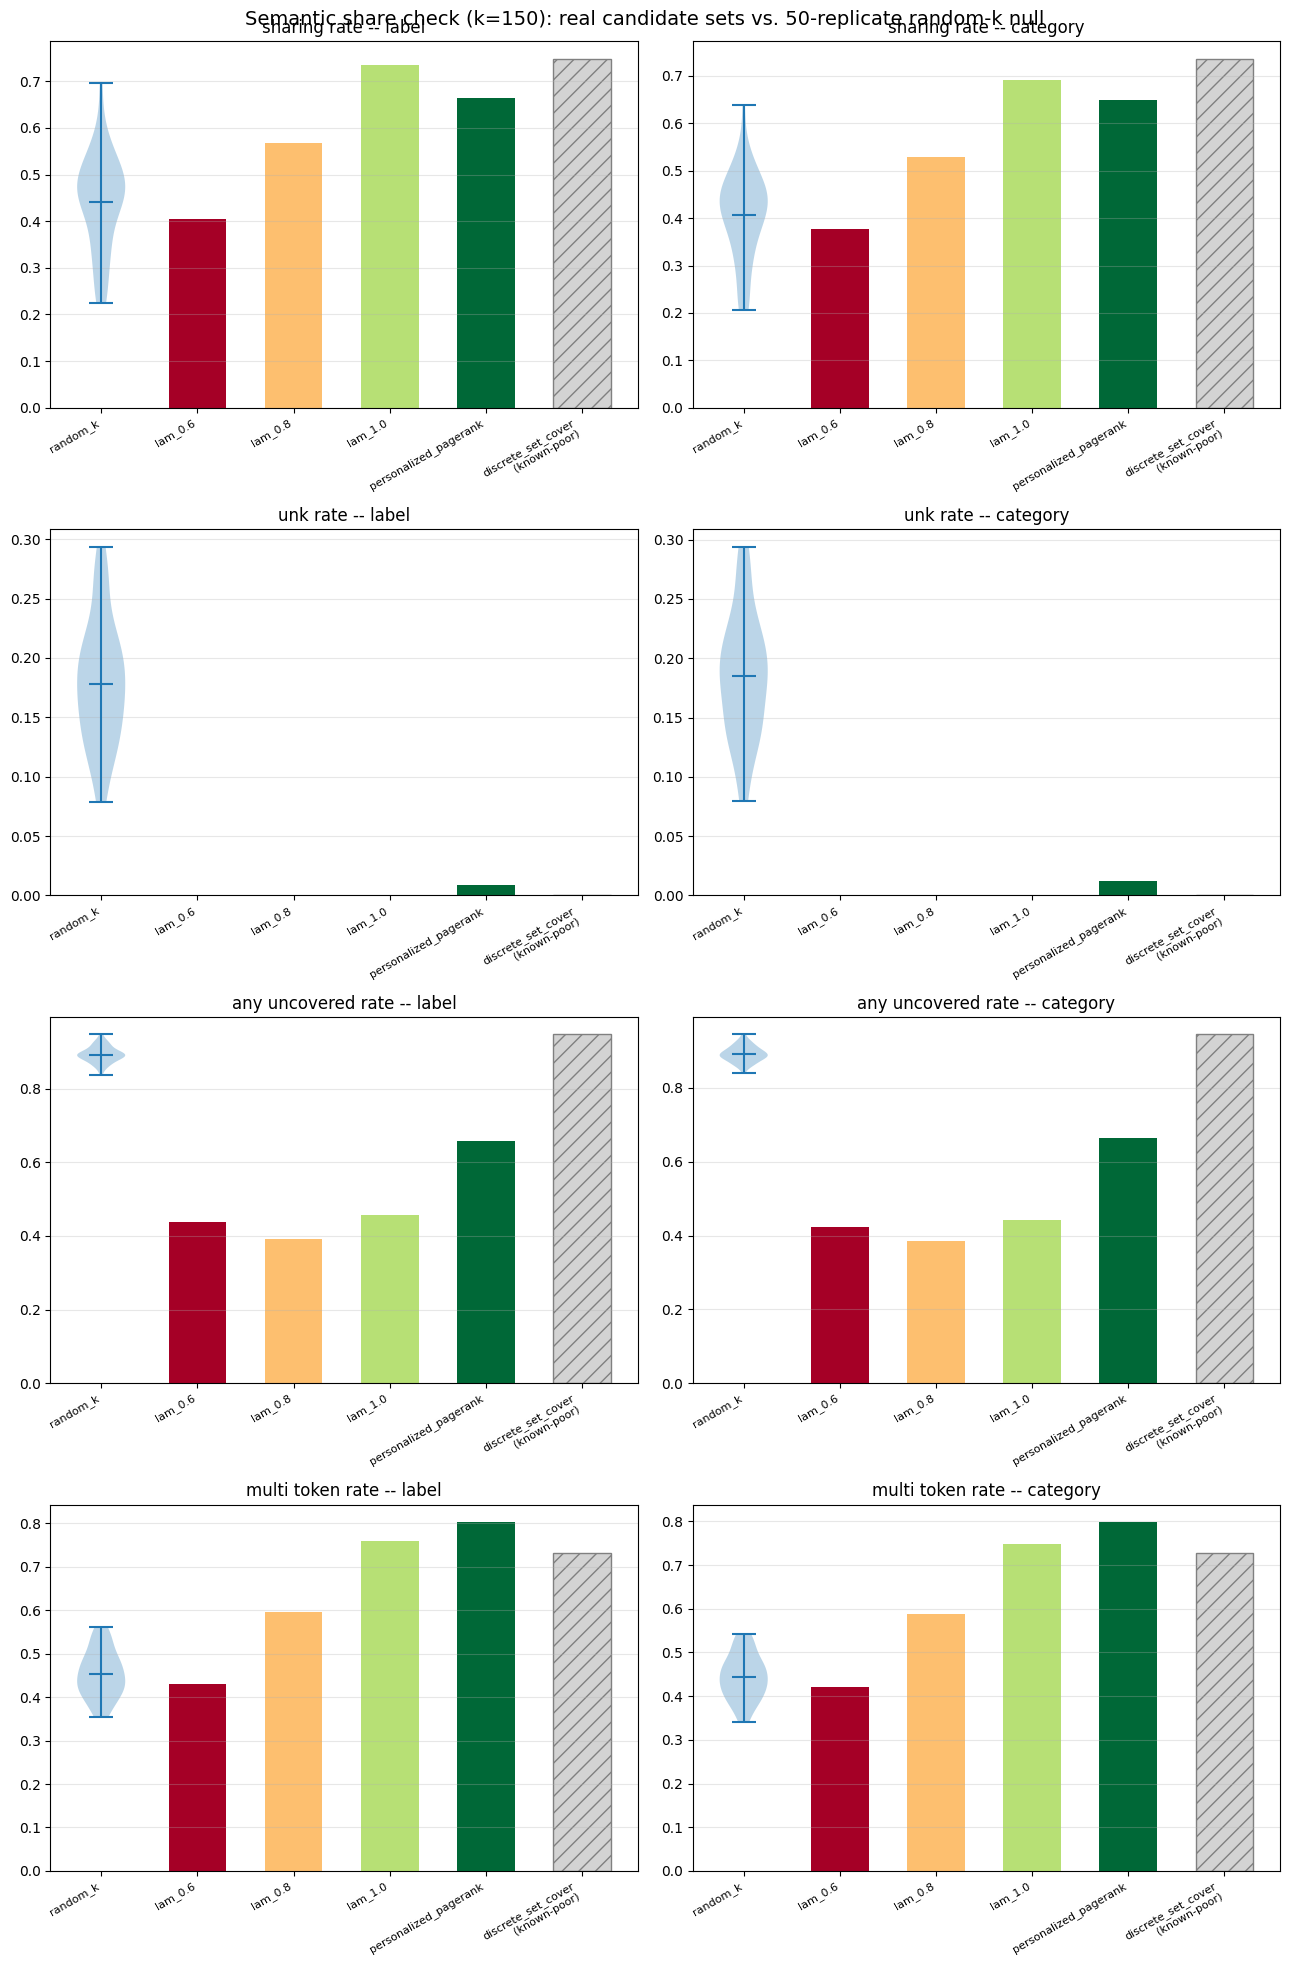

In [90]:
fig, axes = plt.subplots(4, 2, figsize=(13, 20))
plot_metrics = ["sharing_rate", "unk_rate", "any_uncovered_rate", "multi_token_rate"]
plot_grans = ["label", "category"]
cmap = plt.get_cmap("RdYlGn")
method_colors = {m: cmap(i / max(len(MAIN_METHODS) - 1, 1)) for i, m in enumerate(MAIN_METHODS)}

for row, metric in enumerate(plot_metrics):
    for col, gran in enumerate(plot_grans):
        ax = axes[row, col]
        random_vals = random_metrics_df.filter(pl.col("granularity") == gran)[metric].to_list()
        ax.violinplot([random_vals], positions=[0], showmeans=True)

        for i, method in enumerate(MAIN_METHODS):
            val = real_metrics_df.filter((pl.col("method") == method) & (pl.col("granularity") == gran))[metric][0]
            ax.bar(i + 1, val, color=method_colors[method], width=0.6)

        ref_val = real_metrics_df.filter((pl.col("method") == REFERENCE_METHOD) & (pl.col("granularity") == gran))[metric][0]
        ax.bar(len(MAIN_METHODS) + 1, ref_val, color="lightgray", hatch="//", edgecolor="gray", width=0.6)

        ax.set_xticks(range(len(MAIN_METHODS) + 2), ["random_k"] + MAIN_METHODS + [f"{REFERENCE_METHOD}\n(known-poor)"], rotation=30, ha="right", fontsize=8)
        ax.set_title(f"{metric.replace('_', ' ')} -- {gran}")
        ax.grid(alpha=0.3, axis="y")

fig.suptitle(f"Semantic share check (k={K}): real candidate sets vs. {N_RANDOM_REPLICATES}-replicate random-k null", fontsize=14)
fig.tight_layout()
plt.show()

Per-label table, sorted by BH-adjusted p-value, main methods only (`discrete_set_cover`'s rows are
in `per_label_df` too, just filtered out of this view).

In [91]:
with pl.Config(tbl_rows=30):
    print(per_label_df.filter(pl.col("method").is_in(MAIN_METHODS)).sort(["method", "p_value_adj"]))

n_sig = per_label_df.filter(pl.col("method").is_in(MAIN_METHODS) & pl.col("significant")).height
n_total = per_label_df.filter(pl.col("method").is_in(MAIN_METHODS)).height
print(f"\n{n_sig} / {n_total} (method, label) pairs significant at BH < 0.05")

shape: (164, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ method     ┆ label      ┆ n_concepts ┆ sharing_r ┆ random_k_ ┆ p_value   ┆ p_value_a ┆ significa │
│ ---        ┆ ---        ┆ ---        ┆ ate       ┆ mean_shar ┆ ---       ┆ dj        ┆ nt        │
│ str        ┆ str        ┆ i64        ┆ ---       ┆ ing_rate  ┆ f64       ┆ ---       ┆ ---       │
│            ┆            ┆            ┆ f64       ┆ ---       ┆           ┆ f64       ┆ bool      │
│            ┆            ┆            ┆           ┆ f64       ┆           ┆           ┆           │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ lam_0.6    ┆ beta_block ┆ 23         ┆ 0.557312  ┆ 0.504901  ┆ 3.4884e-1 ┆ 1.4302e-1 ┆ true      │
│            ┆ er         ┆            ┆           ┆           ┆ 46        ┆ 44        ┆           │
│ lam_0.6    ┆ CKD        ┆ 9          ┆ 1.0       ┆ 0.826667  ┆ 2.1335e-5 

## Top tokens per (method, category/label)

For each method and each category/label group, which tokens do the most group members'
found-sets include? Same rule as `pairwise_sharing_rate` -- no representative-token reduction, a
concept with several tokens in its found-set counts toward every one of them -- but ranked to keep
the top `TOP_N_TOKENS` tokens per group (by how many members contain them), not just the single
most common one. `token_share` is the fraction of the group's concepts whose found-set contains
that token; groups with fewer than `TOP_N_TOKENS` distinct tokens (or none at all) get
correspondingly fewer rows.

In [107]:
TOP_N_TOKENS = 3


def top_tokens_table(gt_df, gran, token_sets_, top_n=TOP_N_TOKENS):
    ids, groups_ = gt_df["id"].to_list(), gt_df[gran].to_list()
    groups = defaultdict(list)
    for c, g in zip(ids, groups_):
        groups[g].append(c)

    rows = []
    for group_val, members in groups.items():
        n = len(members)
        tok_counts = Counter(tok for c in members for tok in token_sets_[c])  # each concept counts once per token in its found-set, not once total
        top = tok_counts.most_common(top_n) or [(None, 0)]  # keep unresolved groups visible as one None row, instead of dropping them
        for rank, (token, count) in enumerate(top, start=1):
            rows.append({
                "group": group_val,
                "n_concepts": n,
                "rank": rank,
                "token": token,
                "token_label": id_to_label.get(token) if token else None,
                "token_n_concepts": count,
                "token_share": count / n if n else float("nan"),
            })
    return pl.DataFrame(rows)


top_tokens_frames = [
    top_tokens_table(gt, gran, token_sets[method]).with_columns([
        pl.lit(method).alias("method"),
        pl.lit(gran).alias("granularity"),
    ])
    for gran, gt in granularities.items()
    for method in METHOD_NAMES
]
top_tokens_df = pl.concat(top_tokens_frames).select(
    "method", "granularity", "group", "n_concepts",
    "rank", "token", "token_label", "token_n_concepts", "token_share"
).sort(["granularity", "method", "group", "rank"])

# top_tokens_df.write_parquet(f"{config.IAFeatures().path}semantic_share_k150_top_tokens.parquet")
top_tokens_df.head(10)

method,granularity,group,n_concepts,rank,token,token_label,token_n_concepts,token_share
str,str,str,i64,i64,str,str,i64,f64
"""discrete_set_cover""","""category""","""ACE""",13,1,"""734551003""","""Enzyme inhibitor (disposition)""",9,0.692308
"""discrete_set_cover""","""category""","""ACE""",13,2,"""372695000""","""Diuretic (substance)""",6,0.461538
"""discrete_set_cover""","""category""","""ACE""",13,3,"""372586001""","""Hypotensive agent (substance)""",6,0.461538
"""discrete_set_cover""","""category""","""ADPKD""",3,1,"""118972000""","""Structure of urinary system su…",3,1.0
"""discrete_set_cover""","""category""","""ADPKD""",3,2,"""1156676003""","""Fetal and/or neonatal period (…",2,0.666667
"""discrete_set_cover""","""category""","""ADPKD""",3,3,"""113343008""","""Body organ structure (body str…",1,0.333333
"""discrete_set_cover""","""category""","""NSAID""",5,1,"""372665008""","""Non-steroidal anti-inflammator…",5,1.0
"""discrete_set_cover""","""category""","""NSAID""",5,2,"""734551003""","""Enzyme inhibitor (disposition)""",2,0.4
"""discrete_set_cover""","""category""","""PPI""",7,1,"""372590004""","""Ulcer healing agent (substance…",7,1.0


In [ ]:
with pl.Config(tbl_rows=30, fmt_str_lengths=40):
    print(top_tokens_df.filter(pl.col("method").is_in(MAIN_METHODS) & (pl.col("granularity") == "label"))
          .sort(["method", "group", "rank"]))

In [121]:
top_tokens_df.filter(pl.col("n_concepts") > 5).filter(pl.col("granularity") == "label").filter(pl.col("group") == "anticoagulant")

method,granularity,group,n_concepts,rank,token,token_label,token_n_concepts,token_share
str,str,str,i64,i64,str,str,i64,f64
"""discrete_set_cover""","""label""","""anticoagulant""",8,1,"""372862008""","""Anticoagulant (substance)""",8,1.0
"""discrete_set_cover""","""label""","""anticoagulant""",8,2,"""1091008""","""Substance with coagulation fac…",4,0.5
"""discrete_set_cover""","""label""","""anticoagulant""",8,3,"""116280007""","""Heterocyclic compound (substan…",3,0.375
"""lam_0.6""","""label""","""anticoagulant""",8,1,"""116508003""","""Argatroban (substance)""",1,0.125
"""lam_0.6""","""label""","""anticoagulant""",8,2,"""712778008""","""Edoxaban (substance)""",1,0.125
…,…,…,…,…,…,…,…,…
"""lam_1.0""","""label""","""anticoagulant""",8,2,"""726711005""","""Disposition (disposition)""",4,0.5
"""lam_1.0""","""label""","""anticoagulant""",8,3,"""116280007""","""Heterocyclic compound (substan…",3,0.375
"""personalized_pagerank""","""label""","""anticoagulant""",8,1,"""726711005""","""Disposition (disposition)""",4,0.5


## Known issues (carried through from the spec)

- **`label` nests inside `category`.** Both are reported above, but `label` (56 groups, 41 after
  dropping singletons) is the primary/strict result; `category` (41 groups, 36 after dropping
  singletons) is the lenient sanity check -- a method can look good on `category` purely by
  grouping concepts that share a coarse category without sharing a clinically-specific label.
- **This is a small, dense graph, not the full cohort vocab.** `combined_subgraphs` is the ego-graph
  union over 6.5's 268 curated concepts (D=3), which is far smaller than the full ~6,002-concept
  cohort graph used elsewhere in this project. A random 150-candidate draw covers a much larger
  fraction of it than it would of the full cohort graph, so the random-k null here is a stronger
  baseline than "random tokens from the whole vocabulary" would suggest -- real methods have to
  clear a higher bar to look significant. See `random_metrics_df`'s `sharing_rate`/`unk_rate` for
  how strong that baseline actually is on a given run.
- **Concepts can map to several tokens.** `multi_token_rate` in `real_metrics_df`/`random_metrics_df`
  tracks how often a concept's found-set has more than one token. Sharing rate and the per-label
  Fisher's test use the full found-set directly (set intersection), so this never needs to be
  collapsed to a single value anywhere in this notebook.
- **Coverage caveat.** Only 243 of the ~6,002-concept vocab (~4%) has expert labels here. This
  validates a slice, not the whole tokenizer output.
- **`discrete_set_cover` is a known-poor reference, not a fifth method.** Reported separately
  throughout (`reference_summary_df`, the hatched bar, the `discrete_set_cover` rows in
  `per_label_df`), never averaged into `summary_df` -- see `unk_rate`/`any_uncovered_rate` for its
  actual coverage-by-construction-vs-semantic-quality profile at this k.